In [19]:

!pip install -q imagecodecs
import imagecodecs
print("imagecodecs installed")

imagecodecs installed


In [20]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [21]:
from pathlib import Path
import sys

ROOT = Path("/content/drive/MyDrive/ASR_Project/ASR_finalproject_AllisonWivagg_YeritmaryR")
CODE_DIR = ROOT / "FINAL_Codes"

print("ROOT exists:", ROOT.exists())
print("CODE_DIR exists:", CODE_DIR.exists())
print("CODE_DIR:", CODE_DIR)

if CODE_DIR.exists():
    print("\nFiles in FINAL_Codes:")
    for p in CODE_DIR.iterdir():
        print(p.name)
else:
    print("FINAL_Codes folder does not exist.")

ROOT exists: True
CODE_DIR exists: True
CODE_DIR: /content/drive/MyDrive/ASR_Project/ASR_finalproject_AllisonWivagg_YeritmaryR/FINAL_Codes

Files in FINAL_Codes:
datapreprocessing_check.ipynb
segmentation_core_dev.ipynb
__pycache__
segmentation.py
BBBC006_active_passive_compare_MCdropout.ipynb
BBBC039_active_passive_compare_MCdropout.ipynb
combined_active_passive_compare_MCdropout.ipynb


In [22]:
# Force-load segmentation.py directly

!pip install -q tifffile imagecodecs

import sys
import importlib.util
from pathlib import Path

ROOT = Path("/content/drive/MyDrive/ASR_Project/ASR_finalproject_AllisonWivagg_YeritmaryR")
CODE_DIR = ROOT / "FINAL_Codes"
SEGMENTATION_FILE = CODE_DIR / "segmentation.py"

print("ROOT exists:", ROOT.exists())
print("CODE_DIR exists:", CODE_DIR.exists())
print("segmentation.py exists:", SEGMENTATION_FILE.exists())
print("segmentation.py path:", SEGMENTATION_FILE)

spec = importlib.util.spec_from_file_location("segmentation", SEGMENTATION_FILE)
segmentation = importlib.util.module_from_spec(spec)
sys.modules["segmentation"] = segmentation
spec.loader.exec_module(segmentation)

# import functions/classes into notebook namespace
from segmentation import *

print("Loaded segmentation.py")

print("makeActiveSubsetMCDropout exists:", "makeActiveSubsetMCDropout" in globals())
print("pairFiles exists:", "pairFiles" in globals())
print("UNet exists:", "UNet" in globals())

ROOT exists: True
CODE_DIR exists: True
segmentation.py exists: True
segmentation.py path: /content/drive/MyDrive/ASR_Project/ASR_finalproject_AllisonWivagg_YeritmaryR/FINAL_Codes/segmentation.py
Loaded segmentation.py
makeActiveSubsetMCDropout exists: True
pairFiles exists: True
UNet exists: True


In [23]:
#setting the project directory for saving results


ROOT = Path("/content/drive/MyDrive/ASR_Project/ASR_finalproject_AllisonWivagg_YeritmaryR")

DATA_DIR = ROOT / "data"
OUT_DIR = ROOT / "outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)

B006_IMG = DATA_DIR / "b006" / "images"
B006_MASK = DATA_DIR / "b006" / "masks"

print("B006_IMG exists:", B006_IMG.exists())
print("B006_MASK exists:", B006_MASK.exists())

print("number images:", len(listimgs(B006_IMG)))
print("number masks:", len(listimgs(B006_MASK)))

B006_IMG exists: True
B006_MASK exists: True
number images: 1536
number masks: 768


In [24]:
# Set random seed and make sure device is set correctly for reproducibility and performance


seeds = [42, 7, 123]
for seed in seeds:
    setSeed(seed)
    print("Running seed:", seed)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", DEVICE)

Running seed: 42
Running seed: 7
Running seed: 123
Using device: cuda


In [25]:
# Pairing the image and mask files for BBBC006

print("B006 image folder exists:", B006_IMG.exists())
print("B006 mask folder exists:", B006_MASK.exists())

print("Number of image files:", len(listimgs(B006_IMG)))
print("Number of mask files:", len(listimgs(B006_MASK)))

print("\nExample image files:")
for p in listimgs(B006_IMG)[:5]:
    print(p.name)

print("\nExample mask files:")
for p in listimgs(B006_MASK)[:5]:
    print(p.name)

b006Table = pairB006(B006_IMG, B006_MASK, "BBBC006")

print("\nMatched image-mask pairs:", len(b006Table))
print(b006Table.head())

B006 image folder exists: True
B006 mask folder exists: True
Number of image files: 1536
Number of mask files: 768

Example image files:
mcf-z-stacks-03212011_a01_s1_w1248254b0-0193-4e11-8762-62b5d2b86216.tif
mcf-z-stacks-03212011_a01_s1_w29fd6a02e-3931-4457-a5e9-3c6063bf1015.tif
mcf-z-stacks-03212011_a01_s2_w16103c57d-a39e-468b-bb15-d55443c280d9.tif
mcf-z-stacks-03212011_a01_s2_w2722a428b-b51e-4a8a-8310-7feec741e351.tif
mcf-z-stacks-03212011_a02_s1_w166fea8cb-8e72-4999-9f72-ee77bfdac65f.tif

Example mask files:
mcf-z-stacks-03212011_a01_s1.png
mcf-z-stacks-03212011_a01_s2.png
mcf-z-stacks-03212011_a02_s1.png
mcf-z-stacks-03212011_a02_s2.png
mcf-z-stacks-03212011_a03_s1.png

Matched image-mask pairs: 768
                       image_id  \
0  mcf-z-stacks-03212011_a01_s1   
1  mcf-z-stacks-03212011_a01_s2   
2  mcf-z-stacks-03212011_a02_s1   
3  mcf-z-stacks-03212011_a02_s2   
4  mcf-z-stacks-03212011_a03_s1   

                                          image_path  \
0  /content/drive/M

In [26]:
# Pairing the image and mask files to create a DataFrame for the BBBC006 dataset

b006Table = pairB006(B006_IMG, B006_MASK, "BBBC006")

print("Matched image-mask pairs:", len(b006Table))
print(b006Table.head())

Matched image-mask pairs: 768
                       image_id  \
0  mcf-z-stacks-03212011_a01_s1   
1  mcf-z-stacks-03212011_a01_s2   
2  mcf-z-stacks-03212011_a02_s1   
3  mcf-z-stacks-03212011_a02_s2   
4  mcf-z-stacks-03212011_a03_s1   

                                          image_path  \
0  /content/drive/MyDrive/ASR_Project/ASR_finalpr...   
1  /content/drive/MyDrive/ASR_Project/ASR_finalpr...   
2  /content/drive/MyDrive/ASR_Project/ASR_finalpr...   
3  /content/drive/MyDrive/ASR_Project/ASR_finalpr...   
4  /content/drive/MyDrive/ASR_Project/ASR_finalpr...   

                                           mask_path   source  
0  /content/drive/MyDrive/ASR_Project/ASR_finalpr...  BBBC006  
1  /content/drive/MyDrive/ASR_Project/ASR_finalpr...  BBBC006  
2  /content/drive/MyDrive/ASR_Project/ASR_finalpr...  BBBC006  
3  /content/drive/MyDrive/ASR_Project/ASR_finalpr...  BBBC006  
4  /content/drive/MyDrive/ASR_Project/ASR_finalpr...  BBBC006  


In [27]:
# Split the data into training, validation, and test tables

trainingTable, validationTable, testTable = splitData(
    b006Table,
    seed=seed,
    trainSize=0.70,
    validationSize=0.15,
    testSize=0.15
)

print("training size:", len(trainingTable))
print("validation size:", len(validationTable))
print("test size:", len(testTable))

training size: 537
validation size: 115
test size: 116


In [28]:
# Create full segmentation datasets for training, validation, and testing using the SegSet class

trainingSet = SegSet(trainingTable, size=(256, 256), mode="gray")
validationSet = SegSet(validationTable, size=(256, 256), mode="gray")
testSet = SegSet(testTable, size=(256, 256), mode="gray")

print("training dataset size:", len(trainingSet))
print("validation dataset size:", len(validationSet))
print("test dataset size:", len(testSet))

training dataset size: 537
validation dataset size: 115
test dataset size: 116


image shape: torch.Size([1, 256, 256])
mask shape: torch.Size([1, 256, 256])
image id: mcf-z-stacks-03212011_i23_s2
source: BBBC006
split: train


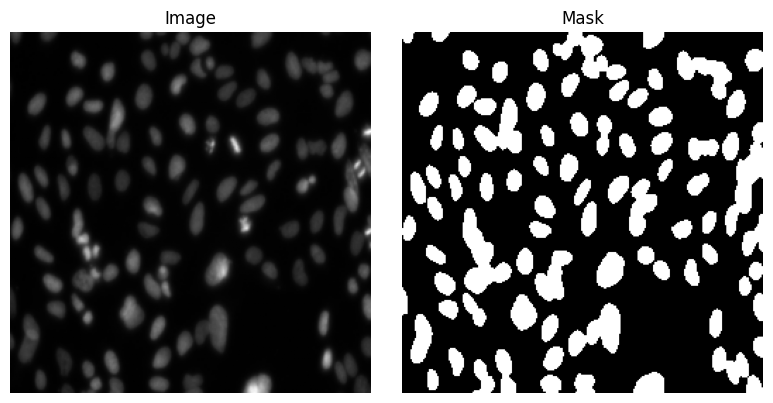

In [29]:
#verifing that the first item in the training set is loaded correctly

sample = trainingSet[0]

print("image shape:", sample["image"].shape)
print("mask shape:", sample["mask"].shape)
print("image id:", sample["image_id"])
print("source:", sample["source"])
print("split:", sample["split"])

plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(sample["image"].squeeze().numpy(), cmap="gray")
plt.title("Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(sample["mask"].squeeze().numpy(), cmap="gray")
plt.title("Mask")
plt.axis("off")

plt.tight_layout()
plt.show()

In [30]:
# Paassive learning subset creation function

def makePassiveSubset(dataset, numberOfSamples=120, seed=seed):
    setSeed(seed)

    allIndexes = list(range(len(dataset)))
    random.shuffle(allIndexes)

    selectedIndexes = allIndexes[:numberOfSamples]

    subset = torch.utils.data.Subset(dataset, selectedIndexes)

    return subset, selectedIndexes



In [31]:
# Create passive learning subset

passiveTrainingSet, passiveIndexes = makePassiveSubset(
    dataset=trainingSet,
    numberOfSamples=40,
    seed=seed
)

print("passive training size:", len(passiveTrainingSet))
print("first passive indexes:", passiveIndexes[:10])

passive training size: 40
first passive indexes: [465, 423, 224, 493, 328, 228, 34, 352, 177, 254]


In [32]:
# Passive subset with same warm-up start as active learning

def makePassiveSubsetWithWarmup(dataset, warmupIndexes, numberOfSamples=120, seed=seed):
    setSeed(seed)

    allIndexes = list(range(len(dataset)))

    remainingIndexes = [
        index for index in allIndexes
        if index not in warmupIndexes
    ]

    random.shuffle(remainingIndexes)

    numberToAdd = numberOfSamples - len(warmupIndexes)

    newPassiveIndexes = remainingIndexes[:numberToAdd]

    selectedIndexes = warmupIndexes + newPassiveIndexes

    subset = torch.utils.data.Subset(dataset, selectedIndexes)

    return subset, selectedIndexes

In [33]:
# Shared warm-up set

warmupTrainingSet, warmupIndexes = makePassiveSubset(
    dataset=trainingSet,
    numberOfSamples=40,
    seed=seed
)

In [34]:
passiveTrainingSet, passiveIndexes = makePassiveSubsetWithWarmup(
    dataset=trainingSet,
    warmupIndexes=warmupIndexes,
    numberOfSamples=120,
    seed=seed
)

print("passive training size:", len(passiveTrainingSet))

passive training size: 120


In [35]:
# Make a small warm-up set for active learning

warmupTrainingSet, warmupIndexes = makePassiveSubset(
    dataset=trainingSet,
    numberOfSamples=40,
    seed=seed
)

warmupTrainingLoader = makeLoader(
    warmupTrainingSet,
    batchSize=4,
    shuffle=True
)

validationLoader = makeLoader(
    validationSet,
    batchSize=4,
    shuffle=False
)

print("warm-up training size:", len(warmupTrainingSet))

warm-up training size: 40


In [36]:
# Train a small warm-up model before active selection

warmupNetwork = UNet(
    inputChannels=1,
    outputChannels=1,
    dropoutRate=0.3
).to(DEVICE)

warmupTrainedNetwork, warmupHistoryTable = trainNetwork(
    network=warmupNetwork,
    trainingLoader=warmupTrainingLoader,
    validationLoader=validationLoader,
    device=DEVICE,
    numEpochs=5,
    learningRate=1e-3,
    savingPath=None
)

warmupHistoryTable

Epoch 1/5 | Batch 1/10 | Loss: 1.3665
Epoch 1/5 | Train Loss: 1.0843 | Validation Loss: 1.2646 | Validation Dice: 0.2671 | Validation IoU: 0.1683
Epoch 2/5 | Batch 1/10 | Loss: 0.9941
Epoch 2/5 | Train Loss: 0.8591 | Validation Loss: 1.0698 | Validation Dice: 0.8187 | Validation IoU: 0.7040
Epoch 3/5 | Batch 1/10 | Loss: 0.8776
Epoch 3/5 | Train Loss: 0.7931 | Validation Loss: 1.0827 | Validation Dice: 0.6919 | Validation IoU: 0.5354
Epoch 4/5 | Batch 1/10 | Loss: 0.9191
Epoch 4/5 | Train Loss: 0.7456 | Validation Loss: 0.8350 | Validation Dice: 0.8095 | Validation IoU: 0.6894
Epoch 5/5 | Batch 1/10 | Loss: 0.6629
Epoch 5/5 | Train Loss: 0.6760 | Validation Loss: 0.6888 | Validation Dice: 0.8694 | Validation IoU: 0.7804


,epoch,trainLoss,validationLoss,validationDice,validationIoU
0,1,1.084283,1.264623,0.267138,0.168323
1,2,0.859104,1.069834,0.818685,0.704028
2,3,0.793055,1.082721,0.691940,0.535387
3,4,0.745625,0.834952,0.809473,0.689391
4,5,0.676026,0.688832,0.869371,0.780410


In [37]:
# Creating the active learning subset using MC dropout uncertainty

activeTrainingSet, activeIndexes, uncertaintyTable = makeActiveSubsetMCDropout(
    dataset=trainingSet,
    trainedNetwork=warmupTrainedNetwork,
    device=DEVICE,
    warmupIndexes=warmupIndexes,
    numberOfSamples=120,
    batchSize=16,
    numMCSamples=5
)

print("active training size:", len(activeTrainingSet))
print("first active indexes:", activeIndexes[:10])
print(uncertaintyTable.head().to_string(index=False))


active training size: 120
first active indexes: [465, 423, 224, 493, 328, 228, 34, 352, 177, 254]
 index  uncertainty
    60     0.049221
   117     0.032715
   355     0.027196
   522     0.026350
   418     0.024941


In [38]:
print("passive size:", len(passiveTrainingSet))
print("active size:", len(activeTrainingSet))

print("warmup size:", len(warmupIndexes))
print("passive unique indexes:", len(set(passiveIndexes)))
print("active unique indexes:", len(set(activeIndexes)))

print("same warmup in passive:", set(warmupIndexes).issubset(set(passiveIndexes)))
print("same warmup in active:", set(warmupIndexes).issubset(set(activeIndexes)))

print("passive-active overlap:", len(set(passiveIndexes) & set(activeIndexes)))

passive size: 120
active size: 120
warmup size: 40
passive unique indexes: 120
active unique indexes: 120
same warmup in passive: True
same warmup in active: True
passive-active overlap: 55


In [39]:
#training passive model

passiveTrainingLoader = makeLoader(passiveTrainingSet, batchSize=4, shuffle=True)
validationLoader = makeLoader(validationSet, batchSize=4, shuffle=False)

passiveNetwork = UNet(
    inputChannels=1,
    outputChannels=1,
    dropoutRate=0.3
).to(DEVICE)

passiveTrainedNetwork, passiveHistoryTable = trainNetwork(
    network=passiveNetwork,
    trainingLoader=passiveTrainingLoader,
    validationLoader=validationLoader,
    device=DEVICE,
    numEpochs=5,
    learningRate=1e-3,
    savingPath=None
)

passiveHistoryTable

Epoch 1/5 | Batch 1/30 | Loss: 1.6237
Epoch 1/5 | Batch 11/30 | Loss: 1.0419
Epoch 1/5 | Batch 21/30 | Loss: 0.7577
Epoch 1/5 | Train Loss: 0.8854 | Validation Loss: 0.8087 | Validation Dice: 0.8606 | Validation IoU: 0.7715
Epoch 2/5 | Batch 1/30 | Loss: 0.7774
Epoch 2/5 | Batch 11/30 | Loss: 0.5671
Epoch 2/5 | Batch 21/30 | Loss: 0.6407
Epoch 2/5 | Train Loss: 0.5720 | Validation Loss: 0.5320 | Validation Dice: 0.9041 | Validation IoU: 0.8382
Epoch 3/5 | Batch 1/30 | Loss: 0.4134
Epoch 3/5 | Batch 11/30 | Loss: 0.5009
Epoch 3/5 | Batch 21/30 | Loss: 0.3370
Epoch 3/5 | Train Loss: 0.4678 | Validation Loss: 0.4029 | Validation Dice: 0.9318 | Validation IoU: 0.8866
Epoch 4/5 | Batch 1/30 | Loss: 0.3214
Epoch 4/5 | Batch 11/30 | Loss: 0.3575
Epoch 4/5 | Batch 21/30 | Loss: 0.4584
Epoch 4/5 | Train Loss: 0.3660 | Validation Loss: 0.3234 | Validation Dice: 0.9334 | Validation IoU: 0.8893
Epoch 5/5 | Batch 1/30 | Loss: 0.2628
Epoch 5/5 | Batch 11/30 | Loss: 0.3029
Epoch 5/5 | Batch 21/30 | L

,epoch,trainLoss,validationLoss,validationDice,validationIoU
0,1,0.885383,0.808747,0.860623,0.771465
1,2,0.572031,0.531964,0.904129,0.838230
2,3,0.467775,0.402882,0.931774,0.886603
3,4,0.365980,0.323423,0.933392,0.889305
4,5,0.302424,0.280358,0.936509,0.895260


In [40]:
# Train active learning model from scratch using selected active examples

activeTrainingLoader = makeLoader(
    activeTrainingSet,
    batchSize=4,
    shuffle=True
)

activeNetwork = UNet(
    inputChannels=1,
    outputChannels=1,
    dropoutRate=0.3
).to(DEVICE)

activeTrainedNetwork, activeHistoryTable = trainNetwork(
    network=activeNetwork,
    trainingLoader=activeTrainingLoader,
    validationLoader=validationLoader,
    device=DEVICE,
    numEpochs=5,
    learningRate=1e-3,
    savingPath=None
)

activeHistoryTable

Epoch 1/5 | Batch 1/30 | Loss: 1.3587
Epoch 1/5 | Batch 11/30 | Loss: 0.8617
Epoch 1/5 | Batch 21/30 | Loss: 0.6606
Epoch 1/5 | Train Loss: 0.8673 | Validation Loss: 0.8800 | Validation Dice: 0.9081 | Validation IoU: 0.8457
Epoch 2/5 | Batch 1/30 | Loss: 0.5041
Epoch 2/5 | Batch 11/30 | Loss: 0.5770
Epoch 2/5 | Batch 21/30 | Loss: 0.5374
Epoch 2/5 | Train Loss: 0.6135 | Validation Loss: 0.5754 | Validation Dice: 0.9209 | Validation IoU: 0.8678
Epoch 3/5 | Batch 1/30 | Loss: 0.4298
Epoch 3/5 | Batch 11/30 | Loss: 0.4747
Epoch 3/5 | Batch 21/30 | Loss: 0.3983
Epoch 3/5 | Train Loss: 0.5139 | Validation Loss: 0.4462 | Validation Dice: 0.9395 | Validation IoU: 0.9005
Epoch 4/5 | Batch 1/30 | Loss: 0.4205
Epoch 4/5 | Batch 11/30 | Loss: 0.4079
Epoch 4/5 | Batch 21/30 | Loss: 0.3616
Epoch 4/5 | Train Loss: 0.4170 | Validation Loss: 0.3794 | Validation Dice: 0.9374 | Validation IoU: 0.8968
Epoch 5/5 | Batch 1/30 | Loss: 0.3103
Epoch 5/5 | Batch 11/30 | Loss: 0.3025
Epoch 5/5 | Batch 21/30 | L

,epoch,trainLoss,validationLoss,validationDice,validationIoU
0,1,0.867326,0.879976,0.908076,0.845690
1,2,0.613464,0.575430,0.920872,0.867760
2,3,0.513945,0.446220,0.939463,0.900455
3,4,0.416971,0.379400,0.937400,0.896771
4,5,0.354607,0.312485,0.938435,0.898847


In [41]:
# Evaluate the passive and active models on the same test set

testLoader = makeLoader(testSet, batchSize=4, shuffle=False)

lossFunction = SegLoss()

passiveTestResults = evaluateNetwork(
    network=passiveTrainedNetwork,
    dataLoader=testLoader,
    lossFunction=lossFunction,
    device=DEVICE
)

activeTestResults = evaluateNetwork(
    network=activeTrainedNetwork,
    dataLoader=testLoader,
    lossFunction=lossFunction,
    device=DEVICE
)

print("Passive test results:")
print(passiveTestResults)

print("\nActive test results:")
print(activeTestResults)

Passive test results:
{'loss': 0.24446789303730274, 'dice': 0.9453126294859524, 'iou': 0.9045937595696285}

Active test results:
{'loss': 0.2777476978713068, 'dice': 0.945843166318433, 'iou': 0.9056049215382543}


In [42]:
# Compare passive and active learning results with a summary table

comparisonTable = pd.DataFrame([
    {
        "strategy": "passive",
        "training_samples": len(passiveTrainingSet),
        "test_loss": passiveTestResults["loss"],
        "test_dice": passiveTestResults["dice"],
        "test_iou": passiveTestResults["iou"]
    },
    {
        "strategy": "active",
        "training_samples": len(activeTrainingSet),
        "test_loss": activeTestResults["loss"],
        "test_dice": activeTestResults["dice"],
        "test_iou": activeTestResults["iou"]
    }
])

comparisonTable

,strategy,training_samples,test_loss,test_dice,test_iou
0,passive,120,0.244468,0.945313,0.904594
1,active,120,0.277748,0.945843,0.905605


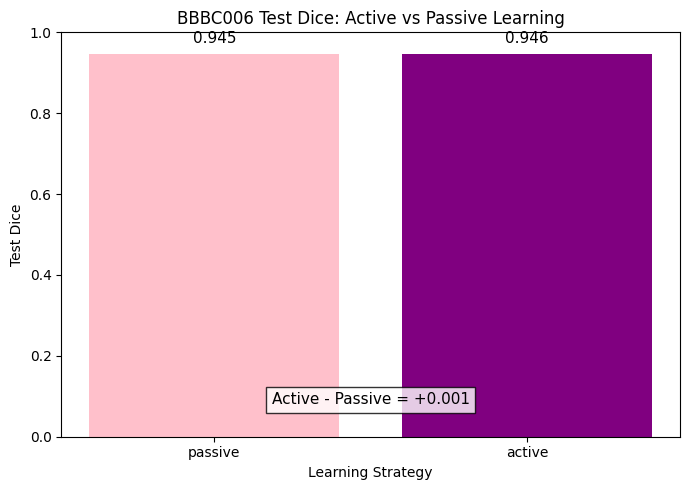

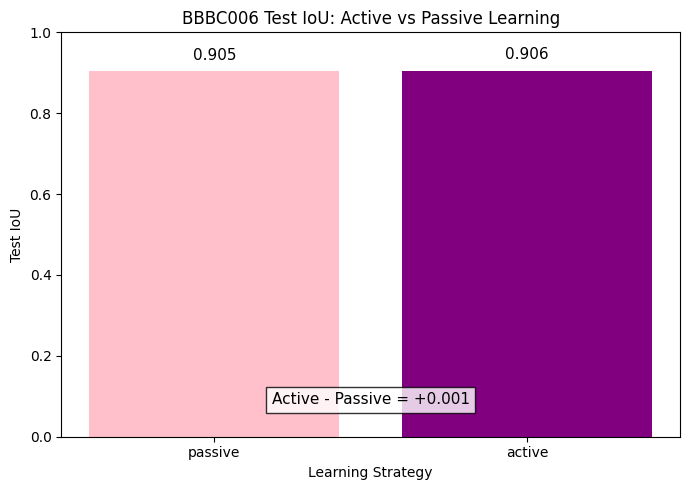

In [43]:

#  Dice and IoU comparison plots for BBBC006 

barColors = ["pink", "purple"]

metrics = [
    ("test_dice", "Dice"),
    ("test_iou", "IoU")
]

for metricColumn, metricName in metrics:
    passiveValue = comparisonTable.loc[
        comparisonTable["strategy"] == "passive", metricColumn
    ].iloc[0]

    activeValue = comparisonTable.loc[
        comparisonTable["strategy"] == "active", metricColumn
    ].iloc[0]

    difference = activeValue - passiveValue

    plt.figure(figsize=(7, 5))

    bars = plt.bar(
        comparisonTable["strategy"],
        comparisonTable[metricColumn],
        color=barColors
    )

    plt.ylabel(f"Test {metricName}")
    plt.xlabel("Learning Strategy")
    plt.title(f"BBBC006 Test {metricName}: Active vs Passive Learning")
    plt.ylim(0, 1)

    # Adding the values above bars
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.02,
            f"{height:.3f}",
            ha="center",
            va="bottom",
            fontsize=11
        )

    
    plt.text(
        0.5,
        0.08,
        f"Active - Passive = {difference:+.3f}",
        ha="center",
        fontsize=11,
        bbox=dict(facecolor="white", alpha=0.8)
    )

    plt.tight_layout()
    plt.show()

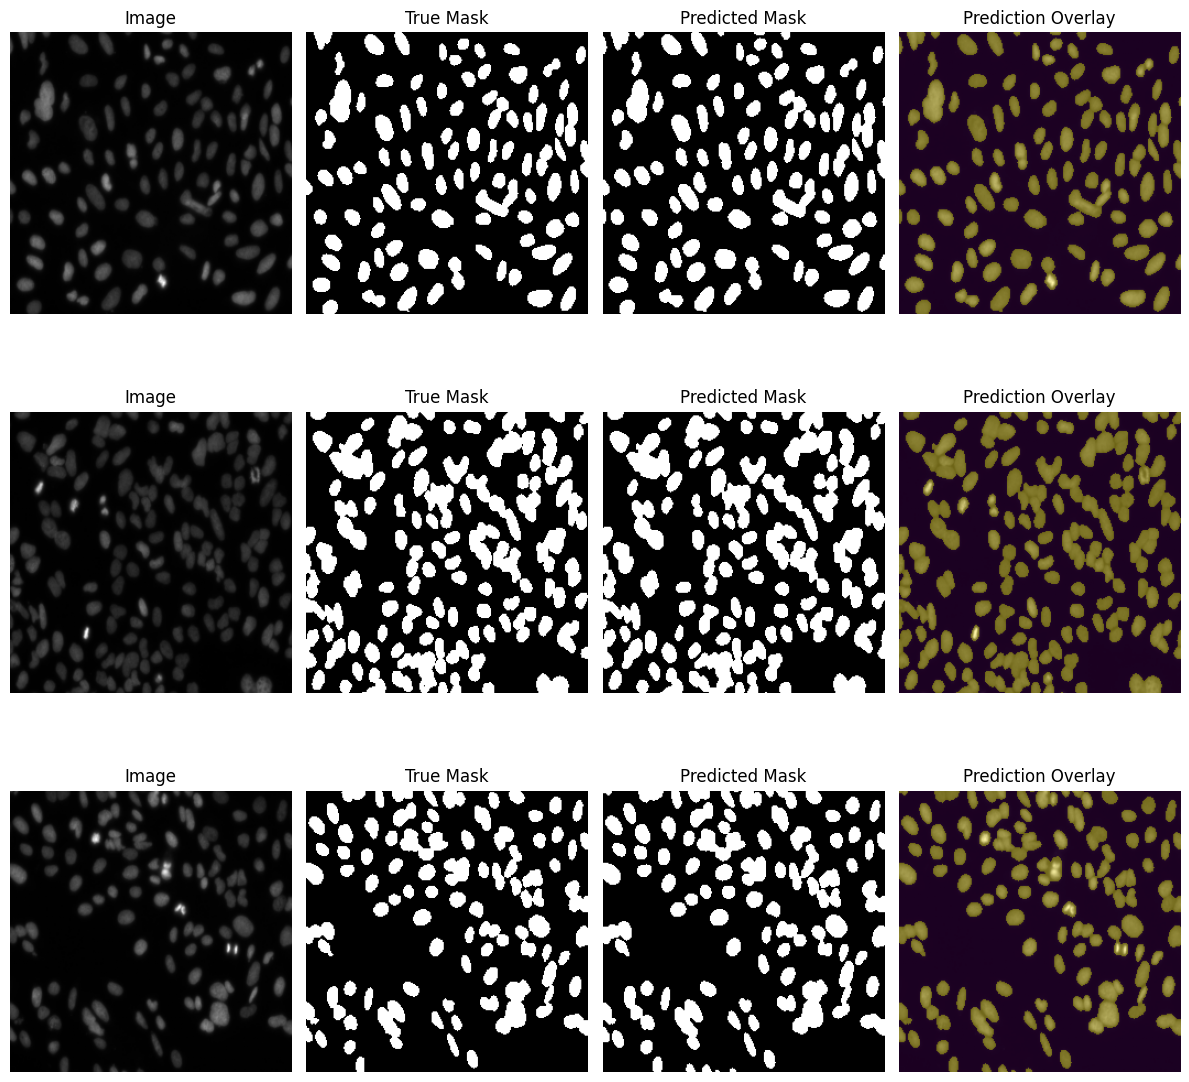

In [44]:
# Passive model predictions

showPredictions(
    network=passiveTrainedNetwork,
    dataset=testSet,
    device=DEVICE,
    numberOfImages=3,
    threshold=0.5
)

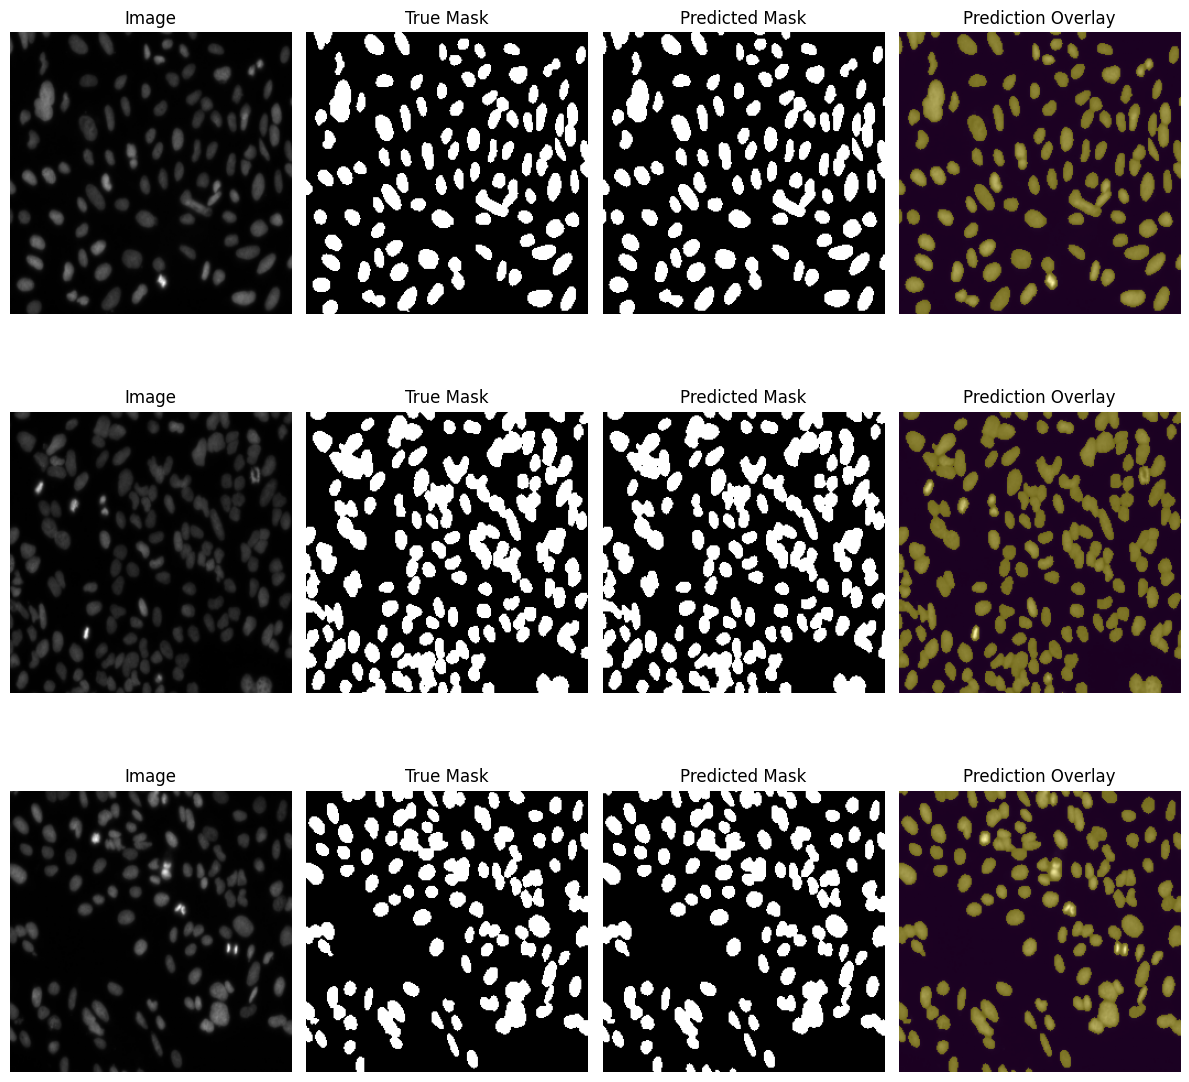

In [45]:
# Show active model predictions

showPredictions(
    network=activeTrainedNetwork,
    dataset=testSet,
    device=DEVICE,
    numberOfImages=3,
    threshold=0.5
)

In [46]:
# Save BBBC006 active/passive comparison results

bbbc006ComparisonPath = OUT_DIR / "BBBC006_active_passive_comparison.csv"
comparisonTable.to_csv(bbbc006ComparisonPath, index=False)

passiveHistoryPath = OUT_DIR / "BBBC006_passive_history.csv"
activeHistoryPath = OUT_DIR / "BBBC006_active_history.csv"

passiveHistoryTable.to_csv(passiveHistoryPath, index=False)
activeHistoryTable.to_csv(activeHistoryPath, index=False)

print("Saved comparison table to:", bbbc006ComparisonPath)
print("Saved passive history to:", passiveHistoryPath)
print("Saved active history to:", activeHistoryPath)

Saved comparison table to: /content/drive/MyDrive/ASR_Project/ASR_finalproject_AllisonWivagg_YeritmaryR/outputs/BBBC006_active_passive_comparison.csv
Saved passive history to: /content/drive/MyDrive/ASR_Project/ASR_finalproject_AllisonWivagg_YeritmaryR/outputs/BBBC006_passive_history.csv
Saved active history to: /content/drive/MyDrive/ASR_Project/ASR_finalproject_AllisonWivagg_YeritmaryR/outputs/BBBC006_active_history.csv


In [47]:
# Compare ground truth, passive prediction, and active prediction on the same test images

def calculateSingleImageMetrics(predictedMask, trueMask, epsilon=1e-7):
    predictedMask = predictedMask.astype(np.float32)
    trueMask = trueMask.astype(np.float32)

    intersection = np.sum(predictedMask * trueMask)
    predictedArea = np.sum(predictedMask)
    trueArea = np.sum(trueMask)
    union = predictedArea + trueArea - intersection

    dice = (2 * intersection + epsilon) / (predictedArea + trueArea + epsilon)
    iou = (intersection + epsilon) / (union + epsilon)

    return dice, iou


def showPassiveActiveComparison(
    passiveNetwork,
    activeNetwork,
    dataset,
    device,
    numberOfImages=3,
    threshold=0.5,
    figureTitle="Passive vs Active Prediction Comparison"
):
    passiveNetwork.eval()
    activeNetwork.eval()

    plt.figure(figsize=(16, 4 * numberOfImages))

    for imageIndex in range(numberOfImages):
        sample = dataset[imageIndex]

        imageTensor = sample["image"].unsqueeze(0).to(device)
        imageToShow = sample["image"].squeeze().cpu().numpy()
        trueMask = sample["mask"].squeeze().cpu().numpy()

        with torch.no_grad():
            passiveLogits = passiveNetwork(imageTensor)
            passiveProbabilities = torch.sigmoid(passiveLogits)
            passiveMask = passiveProbabilities.squeeze().cpu().numpy()
            passiveBinaryMask = (passiveMask > threshold).astype(np.float32)

            activeLogits = activeNetwork(imageTensor)
            activeProbabilities = torch.sigmoid(activeLogits)
            activeMask = activeProbabilities.squeeze().cpu().numpy()
            activeBinaryMask = (activeMask > threshold).astype(np.float32)

        passiveDice, passiveIoU = calculateSingleImageMetrics(
            passiveBinaryMask,
            trueMask
        )

        activeDice, activeIoU = calculateSingleImageMetrics(
            activeBinaryMask,
            trueMask
        )

        # Column 1: original image
        plt.subplot(numberOfImages, 4, imageIndex * 4 + 1)
        plt.imshow(imageToShow, cmap="gray")
        plt.title("Image")
        plt.axis("off")

        # Column 2: ground truth
        plt.subplot(numberOfImages, 4, imageIndex * 4 + 2)
        plt.imshow(trueMask, cmap="gray")
        plt.title("Ground Truth Mask")
        plt.axis("off")

        # Column 3: passive predicted mask
        plt.subplot(numberOfImages, 4, imageIndex * 4 + 3)
        plt.imshow(passiveBinaryMask, cmap="gray")
        plt.title(
            f"Passive Prediction\nDice={passiveDice:.3f}, IoU={passiveIoU:.3f}"
        )
        plt.axis("off")

        # Column 4: active predicted mask
        plt.subplot(numberOfImages, 4, imageIndex * 4 + 4)
        plt.imshow(activeBinaryMask, cmap="gray")
        plt.title(
            f"Active Prediction\nDice={activeDice:.3f}, IoU={activeIoU:.3f}"
        )
        plt.axis("off")

    plt.suptitle(figureTitle, fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

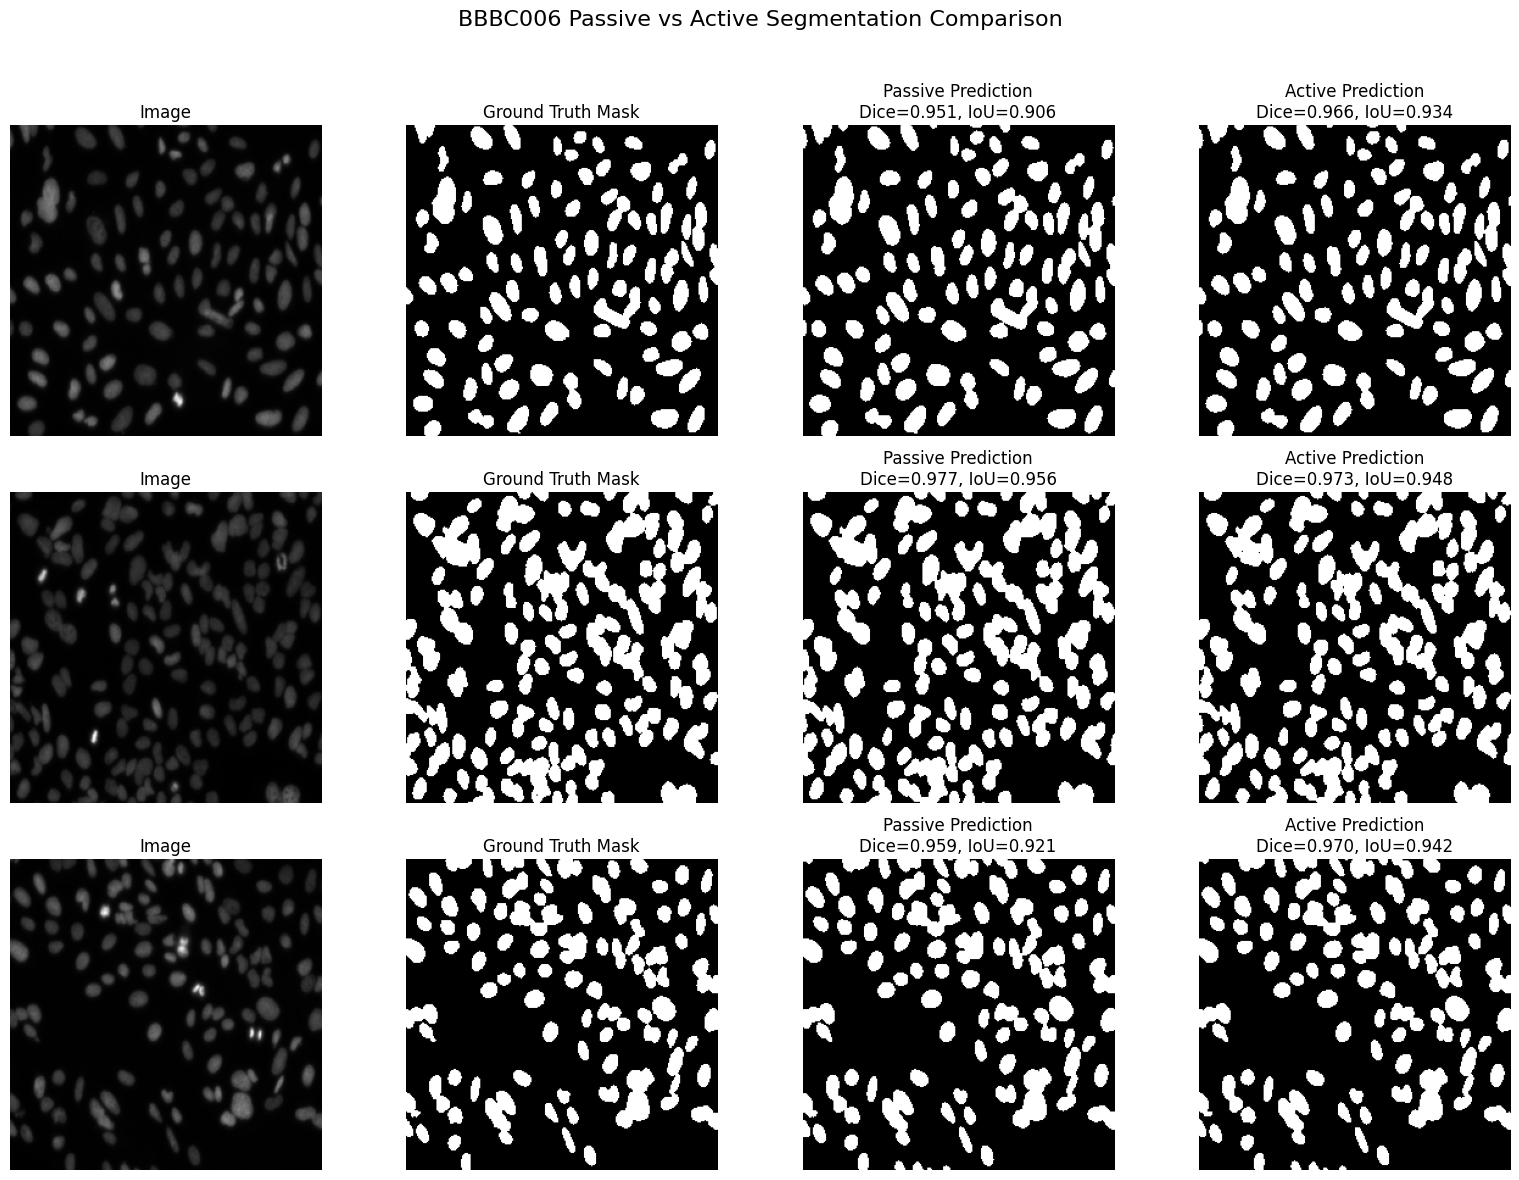

In [48]:
showPassiveActiveComparison(
    passiveNetwork=passiveTrainedNetwork,
    activeNetwork=activeTrainedNetwork,
    dataset=testSet,
    device=DEVICE,
    numberOfImages=3,
    threshold=0.5,
    figureTitle="BBBC006 Passive vs Active Segmentation Comparison"
)